# Nigeria Development Index (1960–2024)
### A Data-Driven Analysis of National Progress Across Six Sectors

---

**Author:** Adelowo Kehinde Adetoyese
**Data Source:** World Bank — World Development Indicators  
**Last Updated:** 2026

---

## What This Project Does

Nigeria is a country of strong opinions and weak data. Arguments about which president ruined the country or which decade was the worst are everywhere — in barbershops, on Twitter, at family dinners. Almost none of those arguments are grounded in numbers.

This project builds a **Nigeria Development Index (NDI)** — a composite scoring system that measures Nigeria's performance across six sectors every year from 1960 to 2024, using real data from the World Bank. It then uses this index to:

1. Track Nigeria's development arc across seven decades
2. Score each democratic president since 1999 on objective sector-by-sector performance

## The Six Sectors

| Sector | What It Measures |
|--------|------------------|
| **Economy** | GDP per capita, inflation, exchange rate, growth, unemployment |
| **Human Development** | Life expectancy, child mortality, water access |
| **Education** | Primary, secondary, tertiary school enrollment |
| **Infrastructure** | Electricity access, internet penetration |
| **Fiscal Health** | Debt, oil dependency, FDI, aid, remittances |
| **Security** | Political stability, voice & accountability, battle deaths |

## Methodology Summary

- Each indicator is normalised to a **0–1 scale** using min-max scaling, where 0 = worst Nigeria ever recorded and 1 = best
- Indicators where higher values are worse (inflation, debt, mortality) are **inverted**
- Indicators are combined using **weighted averages** based on their relative importance within each sector
- Sector scores are aggregated by **decade** and **presidential tenure**

## Data and Methodology Limitations

- The World Bank did not track Nigeria consistently before 1980. Early decade scores should be interpreted with caution.
- Some critical indicators — poverty headcount, literacy rate — have too many gaps to use reliably.
- Presidential tenure averages hide variation *within* a presidency. A president who improved things in year 1 and collapsed them in year 7 scores the same as one who maintained steady mediocrity.
- Oil prices, global economic cycles, and inherited conditions are not fully accounted for in this model.
- This analysis measures *outcomes*, not governance quality. Some outcomes improve regardless of who is in power.

---
## 1. Setup & Data Loading

We import the standard data science stack. The dataset is the World Bank's Nigeria-specific export from the World Development Indicators portal, downloaded as a CSV.

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

The raw World Bank CSV contains 4 rows of metadata (source, date, blank lines) before the actual column headers. We skip these with `skiprows=4` to load cleanly.

In [2]:
# load dataset
NGA_df = pd.read_csv('API_NGA.csv', skiprows=4) # --- skiprows to skip the first 4 rows that we don't need
NGA_df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Nigeria,NGA,"Intentional homicides, male (per 100,000 male)",VC.IHR.PSRC.MA.P5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,24.398705,NaN,NaN,NaN
1,Nigeria,NGA,Battle-related deaths (number of people),VC.BTL.DETH,NaN,NaN,NaN,NaN,NaN,NaN,...,1879.000000,1173.000000,1326.000000,2001.000000,1999.000000,1535.000000,2084.000000,1486.000000,NaN,NaN
2,Nigeria,NGA,Voice and Accountability: Percentile Rank,VA.PER.RNK,NaN,NaN,NaN,NaN,NaN,NaN,...,35.467979,33.009708,34.299519,31.884058,30.434782,31.884058,32.352940,NaN,NaN,NaN
3,Nigeria,NGA,Transport services (% of commercial service ex...,TX.VAL.TRAN.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,...,28.589720,30.589609,43.873397,58.115994,64.055416,45.892200,48.238374,53.997840,NaN,NaN
4,Nigeria,NGA,"Computer, communications and other services (%...",TX.VAL.OTHR.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,...,7.437316,6.745216,5.829683,6.127430,5.600424,7.825128,6.701232,6.789772,NaN,NaN


### Initial Inspection

Before any cleaning, we inspect the dataset to understand its structure and identify issues.

In [3]:
print('Shape:', NGA_df.shape)
print('\nColumn dtypes:')
print(NGA_df.dtypes)
print('\nNull counts (first 5 columns):')
print(NGA_df.iloc[:, :5].isnull().sum())

Shape: (1516, 71)

Column dtypes:
Country Name          str
Country Code          str
Indicator Name        str
Indicator Code        str
1960              float64
                   ...   
2022              float64
2023              float64
2024              float64
2025              float64
Unnamed: 70       float64
Length: 71, dtype: object

Null counts (first 5 columns):
Country Name         0
Country Code         0
Indicator Name       0
Indicator Code       0
1960              1359
dtype: int64


**What we found:**
- **1,516 indicators** spanning every measurable aspect of Nigeria's development
- **71 columns** — Indicator Name, Indicator Code, Country Name, Country Code, then one column per year from 1960 to 2025, plus a trailing empty column (`Unnamed: 70`) caused by a trailing comma in the CSV
- **~63% of year-column values are null** — the World Bank did not track many indicators consistently before the 1990s

The data is in **wide format**: each row is an indicator, each column is a year. This is not suitable for analysis. We will reshape it to **long format** where each row is one indicator × one year × one value.

---
## 2. Data Cleaning & Reshaping

### 2.1 Drop Redundant Columns

Three columns add no analytical value to this single-country dataset:
- `Country Name` — always 'Nigeria'
- `Country Code` — always 'NGA'
- `Indicator Code` — a technical World Bank ID we don't need

In [4]:
NGA_df = NGA_df.drop(columns=['Country Name', 'Country Code', 'Indicator Code'])
print('Shape after dropping columns:', NGA_df.shape)
print('Remaining columns (first 5):', NGA_df.columns[:5].tolist())

Shape after dropping columns: (1516, 68)
Remaining columns (first 5): ['Indicator Name', '1960', '1961', '1962', '1963']


### 2.2 Reshape Wide → Long

We use `pd.melt()` to convert from wide format (years as columns) to long format (one row per indicator per year).

**Before melt:** 1,516 rows × 68 year columns 
**After melt:** 1,516 × 66 = ~100,000 rows (each year becomes its own row)

The only column we keep fixed (`id_vars`) is `Indicator Name`. All year columns collapse into two new columns: `year` and `value`.

In [5]:
df_long = pd.melt(
    NGA_df,
    id_vars='Indicator Name',
    var_name='year',
    value_name='value'
)
df_long.head()

,Indicator Name,year,value
0,"Intentional homicides, male (per 100,000 male)",1960,NaN
1,Battle-related deaths (number of people),1960,NaN
2,Voice and Accountability: Percentile Rank,1960,NaN
3,Transport services (% of commercial service ex...,1960,NaN
4,"Computer, communications and other services (%...",1960,NaN


### 2.3 Remove Unwanted Rows & Fix Data Types

We remove the `Unnamed: 70` rows.

The `year` column is currently a string (it was a column name). We convert it to a nullable integer (`Int64`) to enable time-based operations. We then drop rows where `value` is null — these represent years where the World Bank did not record a particular indicator.

In [6]:
# Remove rows
df_long = df_long[df_long['year'] != 'Unnamed: 70']

# Convert year to integer
df_long['year'] = df_long['year'].astype('Int64')

# Drop null values — years with no recorded data
df_long = df_long.dropna(subset=['value'])

print('Shape after cleaning:', df_long.shape)
print('Year range:', df_long['year'].min(), '–', df_long['year'].max())
print('Dtypes:')
print(df_long.dtypes)

Shape after cleaning: (37020, 3)
Year range: 1960 – 2025
Dtypes:
Indicator Name        str
year                Int64
value             float64
dtype: object


**Result:** ~37,000 non-null rows — down from 100,000. The remaining rows represent actual recorded data points across Nigeria's history.

---
## 3. Sector Filtering

With 1,516 indicators available, we cannot and should not use all of them. We select indicators for six sectors that together answer: *how well is this country actually working for its people?*

**Selection criteria:**
1. The indicator must be directly meaningful for its sector
2. It must have at least 15 non-null years of data from 1980–2023 (minimum threshold for trend analysis)
3. It must not duplicate another selected indicator

We use `.isin()` with exact indicator names for precision — keyword matching risks capturing irrelevant indicators.

In [7]:
# Economy — measures the size, health, and stability of Nigeria's economy
economy = [
    'GDP per capita (current US$)',
    'GDP growth (annual %)',
    'Inflation, consumer prices (annual %)',
    'Official exchange rate (LCU per US$, period average)',
    'Unemployment, total (% of total labor force) (modeled ILO estimate)'
]
df_economy = df_long[df_long['Indicator Name'].isin(economy)]

# Human Development — measures how long and well Nigerians live
human_dev_indicators = [
    'Life expectancy at birth, total (years)',
    'Mortality rate, under-5 (per 1,000 live births)',
    'People using at least basic drinking water services, rural (% of rural population)'
]
df_human_dev = df_long[df_long['Indicator Name'].isin(human_dev_indicators)]

# Education — measures access to schooling at all levels
education_indicators = [
    'School enrollment, primary (% gross)',
    'School enrollment, secondary (% gross)',
    'School enrollment, tertiary (% gross)'
]
df_education = df_long[df_long['Indicator Name'].isin(education_indicators)]

# Infrastructure — measures access to electricity and digital connectivity
infrastructure_indicators = [
    'Access to electricity, rural (% of rural population)',
    'Individuals using the Internet (% of population)'
]
df_infrastructure = df_long[df_long['Indicator Name'].isin(infrastructure_indicators)]

# Fiscal Health — measures Nigeria's financial sustainability and oil dependency
fiscal_indicators = [
    'Oil rents (% of GDP)',
    'External debt stocks, short-term (DOD, current US$)',
    'Net official development assistance and official aid received (constant 2023 US$)',
    'Personal remittances, received (% of GDP)',
    'Foreign direct investment, net inflows (BoP, current US$)'
]
df_fiscal = df_long[df_long['Indicator Name'].isin(fiscal_indicators)]

# Security — measures political stability, democratic accountability, and conflict
# Note: data only available from 1996 onward — this sector is most reliable for presidential analysis
security_indicators = [
    'Political Stability and Absence of Violence/Terrorism: Percentile Rank',
    'Voice and Accountability: Percentile Rank',
    'Battle-related deaths (number of people)'
]
df_security = df_long[df_long['Indicator Name'].isin(security_indicators)]

In [8]:
# confirming complete indicators for each sector
for name, df in [('Economy', df_economy), 
                 ('Human Dev', df_human_dev),
                 ('Education', df_education), 
                 ('Infrastructure', df_infrastructure),
                 ('Fiscal', df_fiscal),
                 ('Security', df_security)]:
    print(f"{name}: {df.shape} | Indicators: {df['Indicator Name'].nunique()}")

Economy: (294, 3) | Indicators: 5
Human Dev: (149, 3) | Indicators: 3
Education: (106, 3) | Indicators: 3
Infrastructure: (63, 3) | Indicators: 2
Fiscal: (274, 3) | Indicators: 5
Security: (66, 3) | Indicators: 3


### 3.1 Add Decade & Presidential Tenure Columns

We add two time classification columns to each sector DataFrame:

- **`decade`** — derived arithmetically: `year - (year % 10)` maps any year to its decade start (e.g. 1985 → 1980)
- **`tenure`** — derived using `pd.cut()` which bins continuous year values into labelled presidential periods

Presidential tenure boundaries follow official dates in office. Years before 1999 are labelled 'Pre-democracy' and will be excluded from the presidential comparison.

In [9]:
# Decade column
for df in [df_economy, df_human_dev, df_education, df_infrastructure, df_fiscal, df_security]:
    df['decade'] = df['year'] - (df['year'] % 10)

# Presidential tenure column
bins   = [1959, 1999, 2007, 2010, 2015, 2023, 2025]
labels = ['Pre-democracy', 'Obasanjo', "Yar'Adua", 'Jonathan', 'Buhari', 'Tinubu']

for df in [df_economy, df_human_dev, df_education, df_infrastructure, df_fiscal, df_security]:
    df['tenure'] = pd.cut(df['year'], bins=bins, labels=labels)

# Reset index on all sector DataFrames
df_economy       = df_economy.reset_index(drop=True)
df_human_dev     = df_human_dev.reset_index(drop=True)
df_education     = df_education.reset_index(drop=True)
df_infrastructure = df_infrastructure.reset_index(drop=True)
df_fiscal        = df_fiscal.reset_index(drop=True)
df_security      = df_security.reset_index(drop=True)

# Verify
print(df_economy[['year', 'decade', 'tenure']].drop_duplicates().head(10))

    year  decade         tenure
0   1960    1960  Pre-democracy
3   1961    1960  Pre-democracy
7   1962    1960  Pre-democracy
11  1963    1960  Pre-democracy
15  1964    1960  Pre-democracy
19  1965    1960  Pre-democracy
23  1966    1960  Pre-democracy
27  1967    1960  Pre-democracy
31  1968    1960  Pre-democracy
35  1969    1960  Pre-democracy


---
## 4. Normalization & Scoring

### Why Normalization?

Our indicators use completely different units — GDP per capita in US dollars, inflation in percentages, life expectancy in years. We cannot meaningfully average or compare raw values across sectors.

**Min-Max Normalization** scales every indicator to a 0–1 range based on its own historical values:

$$\text{normalized} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

Where:
- `0` = worst Nigeria ever recorded for that indicator (across the full 1960–2024 range)
- `1` = best Nigeria ever recorded

### Inversion

For indicators where a higher value is actually worse (inflation, debt, mortality, exchange rate depreciation, battle deaths, oil dependency), we invert the normalized score:

$$\text{inverted} = 1 - \text{normalized}$$

This ensures a score of 1 always means good and 0 always means bad, regardless of the indicator's direction.

### Weighting

Not all indicators matter equally. Rather than a simple average, we apply deliberate weights that reflect each indicator's relative importance within its sector. Weights within each sector sum to 1.0.

**Economy weights:**  GDP per capita 0.30 | Inflation 0.25 | GDP growth 0.20 | Exchange rate 0.15 | Unemployment 0.10

**Human Development weights:** Life expectancy 0.45 | Child mortality 0.35 | Water access 0.20

**Education weights:** Primary enrollment 0.40 | Secondary enrollment 0.40 | Tertiary enrollment 0.20

**Infrastructure weights:** Electricity access 0.60 | Internet usage 0.40

**Fiscal Health weights:** External debt 0.30 | Oil rents 0.25 | Foreign aid 0.20 | FDI 0.15 | Remittances 0.10

**Security weights:** Political stability 0.45 | Voice & accountability 0.35 | Battle deaths 0.20

In [10]:
# Min-max normalization function
def normalize(series):
    x = (series - series.min()) / (series.max() - series.min())
    return x

# Indicators where lower value = worse outcome → invert after normalization
invert_indicators = [
    'Inflation, consumer prices (annual %)',
    'Official exchange rate (LCU per US$, period average)',
    'Unemployment, total (% of total labor force) (modeled ILO estimate)',
    'Mortality rate, under-5 (per 1,000 live births)',
    'Oil rents (% of GDP)',
    'External debt stocks, short-term (DOD, current US$)',
    'Net official development assistance and official aid received (constant 2023 US$)',
    'Battle-related deaths (number of people)'
]

# Weights per indicator
weights = {
    # Economy
    'GDP per capita (current US$)': 0.30,
    'Inflation, consumer prices (annual %)': 0.25,
    'GDP growth (annual %)': 0.20,
    'Official exchange rate (LCU per US$, period average)': 0.15,
    'Unemployment, total (% of total labor force) (modeled ILO estimate)': 0.10,
    # Human Development
    'Life expectancy at birth, total (years)': 0.45,
    'Mortality rate, under-5 (per 1,000 live births)': 0.35,
    'People using at least basic drinking water services, rural (% of rural population)': 0.20,
    # Education
    'School enrollment, primary (% gross)': 0.40,
    'School enrollment, secondary (% gross)': 0.40,
    'School enrollment, tertiary (% gross)': 0.20,
    # Infrastructure
    'Access to electricity, rural (% of rural population)': 0.60,
    'Individuals using the Internet (% of population)': 0.40,
    # Fiscal Health
    'External debt stocks, short-term (DOD, current US$)': 0.30,
    'Oil rents (% of GDP)': 0.25,
    'Net official development assistance and official aid received (constant 2023 US$)': 0.20,
    'Foreign direct investment, net inflows (BoP, current US$)': 0.15,
    'Personal remittances, received (% of GDP)': 0.10,
    # Security
    'Political Stability and Absence of Violence/Terrorism: Percentile Rank': 0.45,
    'Voice and Accountability: Percentile Rank': 0.35,
    'Battle-related deaths (number of people)': 0.20
}

def process_sector(df):
    """
    Applies normalization, inversion, and weighting to a sector DataFrame.
    Each indicator is normalized against its own historical range (groupby).
    Inverted indicators are flipped so 1 always = good, 0 always = bad.
    Weighted scores are computed as normalized * weight.
    Since weights sum to 1, summing weighted scores per year gives the sector score.
    """
    df = df.copy()

    # Normalize each indicator against its own historical range
    df['normalized'] = df.groupby('Indicator Name')['value'].transform(normalize)

    # Invert indicators where lower = better
    df.loc[df['Indicator Name'].isin(invert_indicators), 'normalized'] = \
        1 - df.loc[df['Indicator Name'].isin(invert_indicators), 'normalized']

    # Apply weights
    df['weight'] = df['Indicator Name'].map(weights)
    df['weighted_score'] = df['normalized'] * df['weight']

    return df

df_economy        = process_sector(df_economy)
df_human_dev      = process_sector(df_human_dev)
df_education      = process_sector(df_education)
df_infrastructure = process_sector(df_infrastructure)
df_fiscal         = process_sector(df_fiscal)
df_security       = process_sector(df_security)

---
## 5. Aggregation

### Building Decade & Tenure Scores

We aggregate in two steps:

1. **Yearly sector score** — sum weighted scores across all indicators for each year. Since weights sum to 1, this gives us a single sector score per year between 0 and 1.
2. **Decade / tenure score** — average the yearly scores within each decade or presidential tenure.

We then combine all six sector scores into master tables using `pd.concat()` and `pd.pivot_table()`, and add a composite column that averages all sectors.

In [11]:
def group(df):
    """
    Step 1: Sum weighted scores per year → one sector score per year.
    Step 2: Average yearly scores per decade and per tenure.
    Returns two DataFrames: decade scores and tenure scores.
    """
    yearly = df.groupby(['year', 'decade', 'tenure'])['weighted_score'].sum().reset_index()
    decade = yearly.groupby('decade')['weighted_score'].mean().reset_index()
    tenure = yearly.groupby('tenure')['weighted_score'].mean().reset_index()
    return decade, tenure

decade_economy,   tenure_economy   = group(df_economy)
decade_human_dev, tenure_human_dev = group(df_human_dev)
decade_education, tenure_education = group(df_education)
decade_infra,     tenure_infra     = group(df_infrastructure)
decade_fiscal,    tenure_fiscal    = group(df_fiscal)
decade_security,  tenure_security  = group(df_security)

In [12]:
# Add sector labels before combining
decade_economy['sector']   = 'economy'
decade_human_dev['sector'] = 'human_dev'
decade_education['sector'] = 'education'
decade_infra['sector']     = 'infrastructure'
decade_fiscal['sector']    = 'fiscal'
decade_security['sector']  = 'security'

tenure_economy['sector']   = 'economy'
tenure_human_dev['sector'] = 'human_dev'
tenure_education['sector'] = 'education'
tenure_infra['sector']     = 'infrastructure'
tenure_fiscal['sector']    = 'fiscal'
tenure_security['sector']  = 'security'

# Combine into master long-format tables
master_decade = pd.concat([
    decade_economy, decade_human_dev, decade_education,
    decade_infra, decade_fiscal, decade_security
]).reset_index(drop=True)

master_tenure = pd.concat([
    tenure_economy, tenure_human_dev, tenure_education,
    tenure_infra, tenure_fiscal, tenure_security
]).reset_index(drop=True)

# Pivot to wide format: rows = decade/tenure, columns = sector
decade_score = pd.pivot_table(
    master_decade, values='weighted_score',
    index='decade', columns='sector', aggfunc='mean'
)

tenure_score = pd.pivot_table(
    master_tenure, values='weighted_score',
    index='tenure', columns='sector', aggfunc='mean'
)

# Add composite score (mean across all sectors)
decade_score['composite'] = decade_score.mean(axis=1)
tenure_score['composite'] = tenure_score.mean(axis=1)

print('=== DECADE SCORES ===')
print(decade_score.round(3))
print('\n=== TENURE SCORES ===')
print(tenure_score.round(3))

=== DECADE SCORES ===
sector  economy  education  fiscal  human_dev  infrastructure  security  \
decade                                                                    
1960      0.460        NaN   0.194      0.036             NaN       NaN   
1970      0.477      0.155   0.666      0.272             NaN       NaN   
1980      0.480      0.527   0.671      0.418             NaN       NaN   
1990      0.519      0.339   0.622      0.423           0.245     0.406   
2000      0.632      0.566   0.689      0.613           0.442     0.354   
2010      0.710      0.608   0.619      0.820           0.694     0.442   
2020      0.524      0.623   0.323      0.803           0.842     0.429   

sector  composite  
decade             
1960        0.230  
1970        0.392  
1980        0.524  
1990        0.426  
2000        0.549  
2010        0.649  
2020        0.591  

=== TENURE SCORES ===
sector         economy  education  fiscal  human_dev  infrastructure  \
tenure                     

---
## 6. Analysis & Visualisation

### 6.1 Nigeria's Development Arc — Composite Score by Decade

The first chart shows Nigeria's overall development trajectory from the 1960s to the 2020s. Each point represents the average composite score for that decade across all six sectors.

Key historical events are annotated directly on the chart to contextualise the rises and dips.

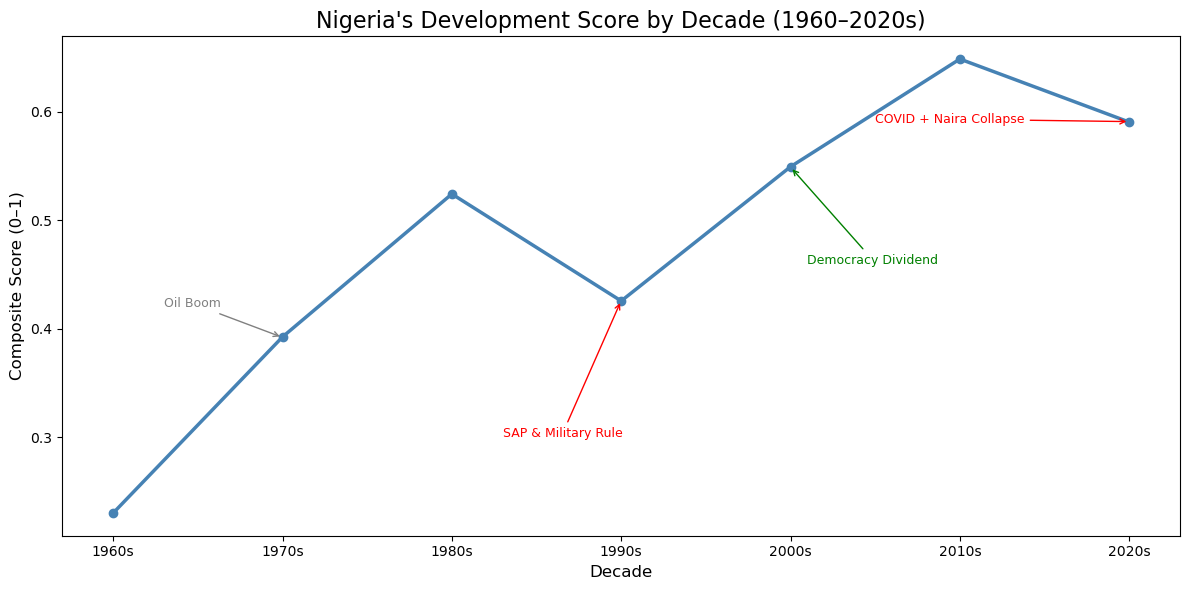

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(decade_score.index, decade_score['composite'],
        marker='o', linewidth=2.5, color='steelblue')

# Historical annotations
ax.annotate('Oil Boom', xy=(1970, 0.392), xytext=(1963, 0.42),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='gray')
ax.annotate('SAP & Military Rule', xy=(1990, 0.426), xytext=(1983, 0.30),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=9, color='red')
ax.annotate('Democracy Dividend', xy=(2000, 0.549), xytext=(2001, 0.46),
            arrowprops=dict(arrowstyle='->', color='green'), fontsize=9, color='green')
ax.annotate('COVID + Naira Collapse', xy=(2020, 0.591), xytext=(2005, 0.59),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=9, color='red')

ax.set_title("Nigeria's Development Score by Decade (1960–2020s)", fontsize=16)
ax.set_xlabel('Decade', fontsize=12)
ax.set_ylabel('Composite Score (0–1)', fontsize=12)
ax.set_xticks(decade_score.index)
ax.set_xticklabels(['1960s', '1970s', '1980s', '1990s', '2000s', '2010s', '2020s'])

plt.tight_layout()
plt.savefig('chart1_decade_composite.png', dpi=150, bbox_inches='tight')
plt.show()

**Reading the chart:**
- The 1990s dip is the sharpest decline — military rule, SAP, and international isolation visibly dragged every sector
- The 2000s recovery reflects the debt relief Obasanjo negotiated, oil price recovery, and the early democracy dividend
- The 2010s represent Nigeria's best decade by this metric — infrastructure and human development improvements drove the score up
- The 2020s decline captures COVID-19's impact, the naira collapse, and deteriorating fiscal health

### 6.2 Sector Trajectories by Decade

This chart shows all six sectors as separate lines, revealing which sectors drove or dragged the overall score in each decade.

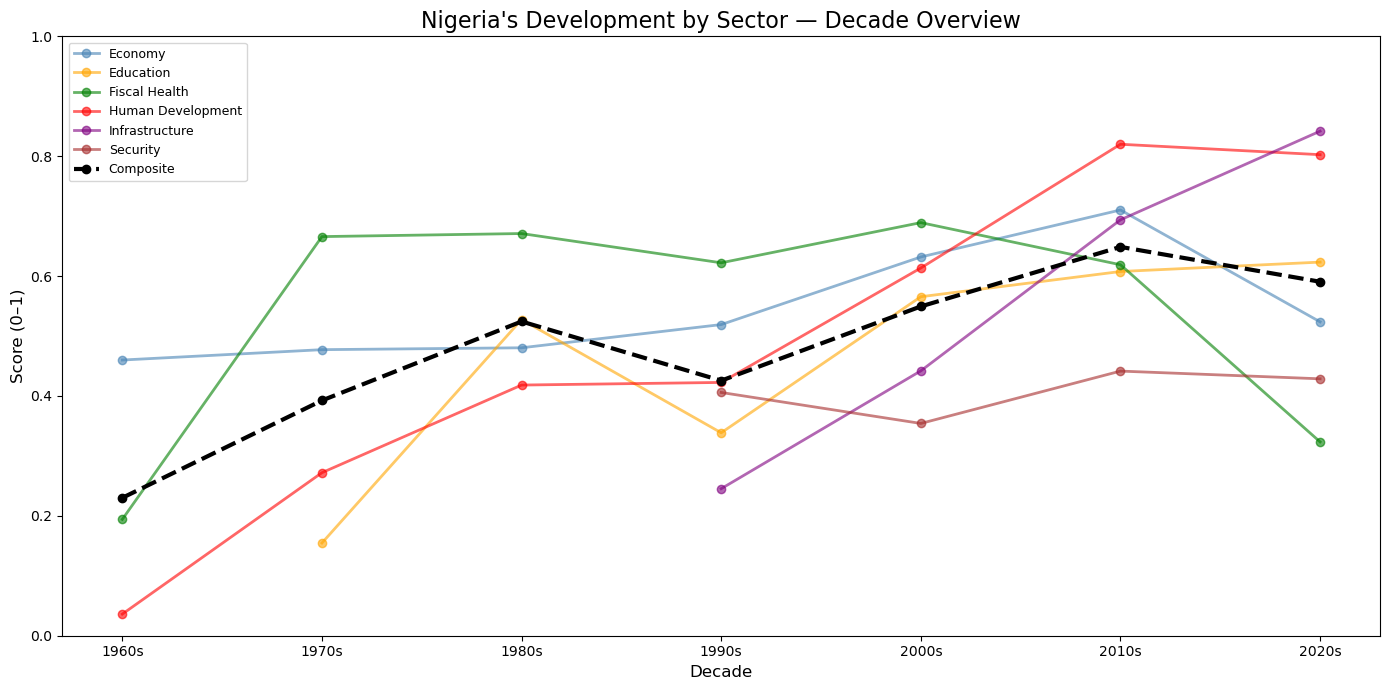

In [14]:
fig, ax = plt.subplots(figsize=(14, 7))

sectors = ['economy', 'education', 'fiscal', 'human_dev', 'infrastructure', 'security', 'composite']
colors  = ['steelblue', 'orange', 'green', 'red', 'purple', 'brown', 'black']
labels  = ['Economy', 'Education', 'Fiscal Health', 'Human Development', 'Infrastructure', 'Security', 'Composite']

for sector, color, label in zip(sectors, colors, labels):
    ax.plot(
        decade_score.index,
        decade_score[sector],
        marker='o',
        linewidth=2 if sector != 'composite' else 3,
        linestyle='-' if sector != 'composite' else '--',
        color=color,
        label=label,
        alpha=0.6 if sector != 'composite' else 1.0
    )

ax.set_title("Nigeria's Development by Sector — Decade Overview", fontsize=16)
ax.set_xlabel('Decade', fontsize=12)
ax.set_ylabel('Score (0–1)', fontsize=12)
ax.set_xticks(decade_score.index)
ax.set_xticklabels(['1960s', '1970s', '1980s', '1990s', '2000s', '2010s', '2020s'])
ax.legend(loc='upper left', fontsize=9)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('chart2_sector_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

**Key observations:**
- **Human Development (red)** shows the most consistent upward trend — improving under every government, driven by long-term gains in healthcare and life expectancy
- **Fiscal Health (green)** is the most volatile — the oil boom and bust cycles are directly visible
- **Security (brown)** never crosses 0.5 — Nigeria has never had a decade where security was not a crisis
- **Education (orange)** is stubbornly flat — no government has moved this needle meaningfully
- **Infrastructure (purple)** only appears from the 1990s onward, then rises sharply in the 2020s as electricity and internet access improved

### 6.3 Presidential Performance — Composite Ranking

We exclude Pre-democracy (39-year military era, not a single president) and Tinubu (only 2 years of data, heavily skewed by missing indicators). The remaining four presidents cover Nigeria's democratic era from 1999–2023.

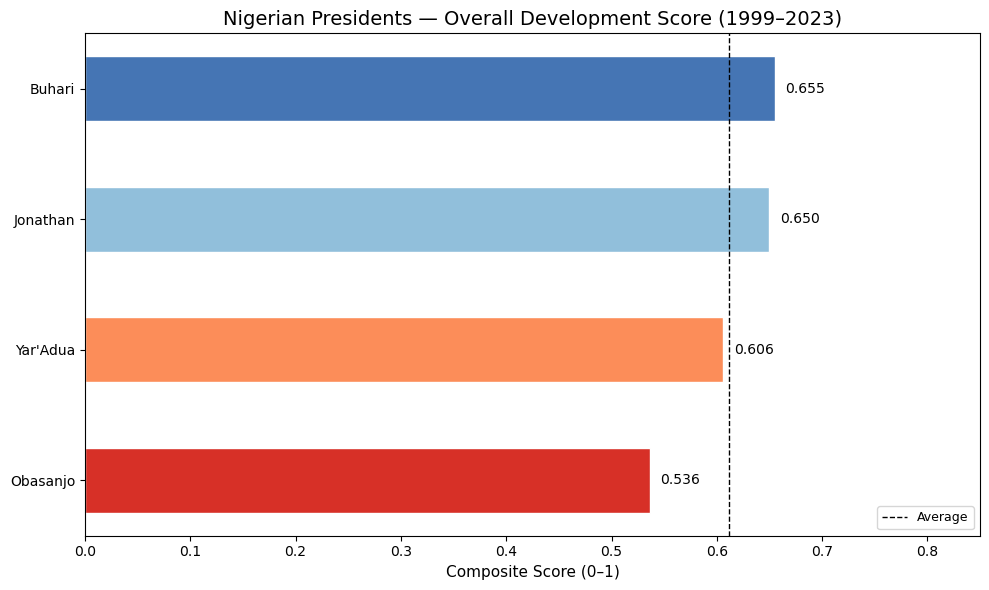

In [19]:
# Filter to democratic presidents with sufficient data
presidents = tenure_score[~tenure_score.index.isin(['Pre-democracy', 'Tinubu'])]

fig, ax = plt.subplots(figsize=(10, 6))

presidents_sorted = presidents.sort_values('composite', ascending=True)

bars = ax.barh(
    presidents_sorted.index,
    presidents_sorted['composite'],
    color=['#d73027', '#fc8d59', '#91bfdb', '#4575b4'],
    edgecolor='white',
    height=0.5
)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{width:.3f}', va='center', fontsize=10)

ax.set_title("Nigerian Presidents — Overall Development Score (1999–2023)", fontsize=14)
ax.set_xlabel('Composite Score (0–1)', fontsize=11)
ax.set_xlim(0, 0.85)
ax.axvline(x=presidents['composite'].mean(), color='black',
           linestyle='--', linewidth=1, label='Average')
ax.legend(fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('chart3_presidential_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

**Important caveat:** A higher composite score does not mean a better president — it means better measured outcomes averaged across their tenure. Buhari scoring highest does not mean he was a good president. It means two sectors (human development and infrastructure) scored very high during his years, which pulled up his average despite fiscal collapse. Context matters — see the heatmap below.

### 6.4 Presidential Performance — Sector Heatmap

The heatmap reveals the full picture behind each president's composite score — showing which sectors were strong (green) and which were weak (red/orange) during each tenure.

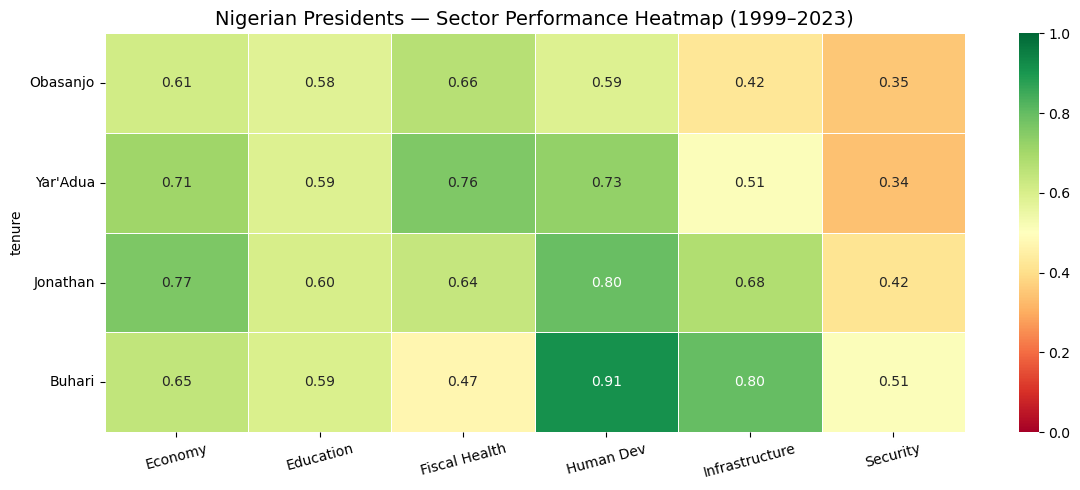

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.heatmap(
    presidents[['economy', 'education', 'fiscal', 'human_dev', 'infrastructure', 'security']],
    annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=0, vmax=1,
    linewidths=0.5, linecolor='white',
    ax=ax
)

ax.set_title("Nigerian Presidents — Sector Performance Heatmap (1999–2023)", fontsize=14)
ax.set_xlabel('')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_xticklabels(['Economy', 'Education', 'Fiscal Health', 'Human Dev', 'Infrastructure', 'Security'],
                   rotation=15)

plt.tight_layout()
plt.savefig('chart4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**What the heatmap reveals:**
- **Security is orange/yellow for every president** — no democratic leader has solved Nigeria's security problem
- **Education hovers around 0.58–0.60 for all four** — stubbornly consistent neglect across administrations
- **Buhari's fiscal health (0.47) is the only deep orange cell** — the naira collapse and debt accumulation visible in a single number
- **Human Development keeps getting greener** going from Obasanjo to Buhari — a long-term improvement trend independent of who was in power
- **Jonathan's economy (0.77)** is the highest economy score of any president — coinciding with historically high global oil prices

### 6.5 Presidential Report Cards — Radar Charts

Radar charts show each president's *shape* across all six sectors simultaneously. A larger, rounder shape indicates balanced strength. A lopsided shape reveals sectoral imbalances.

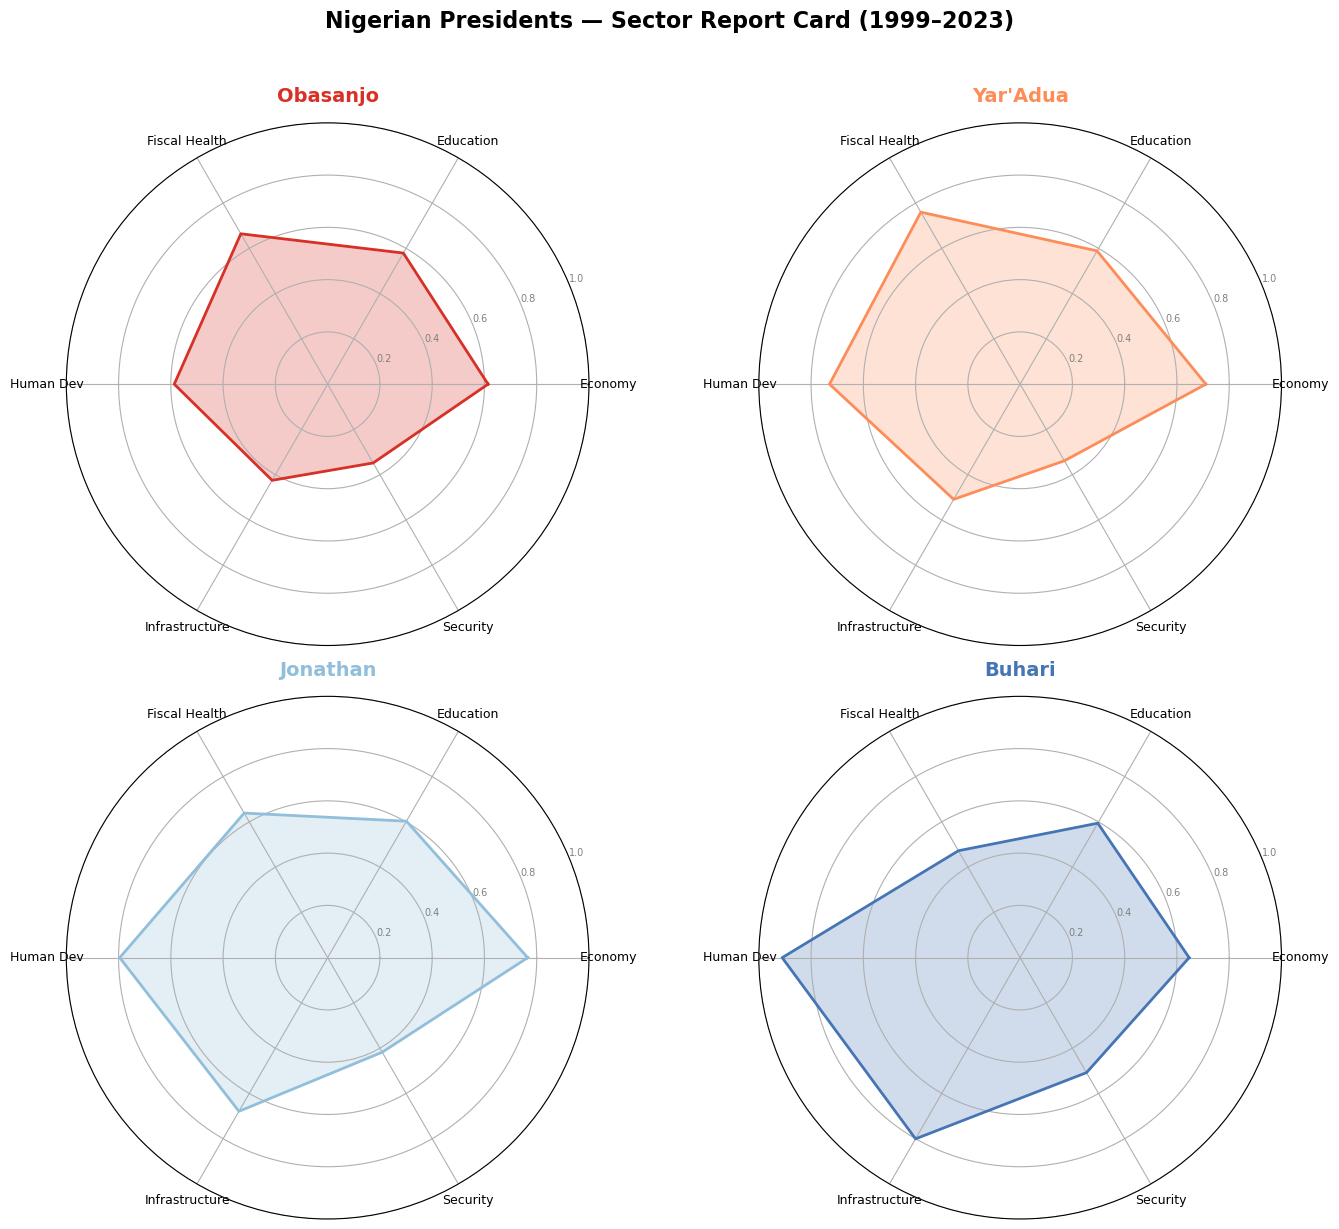

In [17]:
sectors_radar = ['Economy', 'Education', 'Fiscal Health', 'Human Dev', 'Infrastructure', 'Security']
sector_keys   = ['economy', 'education', 'fiscal', 'human_dev', 'infrastructure', 'security']

angles = np.linspace(0, 2 * np.pi, len(sectors_radar), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

colors = {
    'Obasanjo': '#d73027',
    "Yar'Adua": '#fc8d59',
    'Jonathan': '#91bfdb',
    'Buhari':   '#4575b4'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 12), subplot_kw=dict(polar=True))
axes = axes.flatten()

for i, (president, color) in enumerate(zip(presidents.index, colors.values())):
    ax = axes[i]
    values = presidents.loc[president, sector_keys].tolist()
    values += values[:1]

    ax.plot(angles, values, color=color, linewidth=2)
    ax.fill(angles, values, color=color, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(sectors_radar, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=7, color='gray')
    ax.set_title(president, fontsize=14, fontweight='bold', color=color, pad=15)

fig.suptitle("Nigerian Presidents — Sector Report Card (1999–2023)",
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('chart5_radar.png', dpi=150, bbox_inches='tight')
plt.show()

**Shape analysis:**
- **Obasanjo** — compact, relatively even. The shape of a foundation-builder. No standout strengths, security visibly collapsed inward.
- **Yar'Adua** — the largest, most balanced shape. The shape of unrealised potential — he died in office after just 3 years.
- **Jonathan** — balanced with a deep Security dip. Boko Haram is visible in the shape. Economy pushes furthest out.
- **Buhari** — the most lopsided. Human Dev and Infrastructure balloon outward. Fiscal Health collapses inward sharply. The shape of misplaced priorities.

---
## 7. Conclusions

### What the Data Says

1. **Nigeria has broadly improved since independence** — but the progress is uneven and fragile. The 2020s decline shows how quickly gains can be reversed.

2. **No president has fixed security** — it is the one sector where the data is unambiguous. Every democratic government has failed here.

3. **Education is the silent scandal** — the flattest line across six decades of data. No government has treated it as the emergency it is.

4. **Human development improves regardless of leadership** — life expectancy and child mortality move slowly over time. No single president deserves full credit or blame.

5. **The naira tells the fiscal story** — the sharp fiscal decline in recent years is the defining economic legacy of the current era.

### What the Data Cannot Say

This analysis does not measure corruption, institutional quality, lived experience of poverty, or the damage done by policies that don't show up in World Bank indicators for years. A president can score well here and still have been a disaster for ordinary Nigerians.

The numbers are a starting point for an honest conversation — not the final verdict.

---
*Full code and data available on GitHub. All analysis done in Python using pandas, matplotlib, and seaborn.*

In [18]:
# Check which dataset you're actually using
print(NGA_df.shape)  # Should be (1516, 71)

(1516, 68)
